# ❓ Overview
## Historical Analysis {#history}
The passage of the New Deal created a historic realignment with blue-collar and low-income voters and the Democratic Party. The promise of economic opportunity amidst the Great Depression caused a massive influx of working-class voters, predominantly in the American South, to the Democratic Party. As a result, the composition of the average Democratic voter changed heavily, and this remained true until other shifts in party realignment during the 1960s to 1970s with the Vietnam War. The diluted sense of party composition and average voters stuck throughout time. The Democratic Party became the party for the “Common Man”, working to create better conditions for the working class and lower economic classes, while the Republican Party adopted a limited-government and pro-upper-class sentiment. However, following the Vietnam War, the working class has slowly trickled out of supporting the Democratic Party. Despite continuously working for economic policies that would otherwise benefit the working class, working-class voters were losing interest and support levels within the Party. Within the last 20 years, this lack of support for Democratic economic policies has become extremely apparent, as well as the rise in working-class support in the Republican Party. 

## Research Question 
This project looks to *assess the trends of the way the working class votes on policies that are produced by the Democratic Party*. Understanding this is important, as the economic policies created by the Democratic Party are written with the working class in mind. Passage of the policies would benefit working-class voters, who typically do not have access to healthcare benefits, livable wages, and higher-paying jobs. This study also seeks to understand if region, race, and educational attainment have an impact on working voters, as well as certain social policy issues. 

## Data Source + Codebook 
To complete this study, all data were taken from the *Cooperative Election Study Recontact Survey*. The data includes survey results from 2020 to 2024. A **[comprehensive codebook](https://docs.google.com/document/d/151ItLOr0ol4xNrCLPrFgQj6nstP7IN__oTe6nEcbXoQ/edit?usp=sharing)** for this study is available, as is an in-depth codebook provided by CES. 

In [2]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, math, seaborn as sns, plotly.express as px, plotly.io as pio
sns.set_style("whitegrid")
pio.renderers.default = "notebook_connected" # I was having an issue making my maps interactive when I went to do the quarto preview, and Gemini said to do this

In [3]:
# Data setup creating more expansive dataset (copy + paste from midterm + additional variables)

# import data
my_cols = ['pid3_24', 'pid3_22', 'pid3_20', # party id
           'CC24_320a', 'CC22_320a', 'CC20_320a', # presidential approval 
           'RC24_327a', 'CC22_327a', 'CC20_327a', #healthcare 
           'faminc_new_24', # family household income 
           'RC24_355d', 'CC22_355d', #minimum wage 
           'RC24_327c', 'CC22_327c', 'CC20_327d', # aca
           'CC20_355b_24', 'CC20_355b_22', 'CC20_355b_20', # free trade
          'educ_24', 'educ_22', 'educ_20', # educational attainment 
          'race_24', 'race_22', 'race_20', # race
          'region_24', 'region_22', 'region_20', # region 
          'CC24_300a', 'CC22_300a', 'CC20_300a', # media use - TV local vs national 
          "CC24_300b_1", 'CC22_300b_1', 'CC20_300b_1', # media - abc
          "CC24_300b_2", 'CC22_300b_2', 'CC20_300b_2', # media - cbs
          "CC24_300b_3", 'CC22_300b_3', 'CC20_300b_3', # media - nbc
          "CC24_300b_5", 'CC22_300b_5', 'CC20_300b_5', # media - fox
           'RC24_331d', 'CC22_331d', 'CC20_331e', # build a wall 
           'RC24_332f', 'CC22_332f', 'CC20_332f', # ban all abortion 
           'RC24_330c', 'CC22_330c', 'CC20_330c', # easier for concealed carry permit
           'inputstate_24', 'inputstate_22', 'inputstate_20',
           'CC24_323f'
          ]  

df = pd.read_csv('merged_recontact_2024_vv.csv', low_memory = False, usecols = my_cols)

# Cleaning up values in columns I don't need 
party_id = ['pid3_24', 'pid3_22', 'pid3_20']
pres_approval = ['CC24_320a', 'CC22_320a', 'CC20_320a']
healthcare = ['RC24_327a', 'CC22_327a', 'CC20_327a']
income = ['faminc_new_24']
min_wage = ['RC24_355d', 'CC22_355d']
aca = ['RC24_327c', 'CC22_327c', 'CC20_327d']
free_trade = ['CC20_355b_24', 'CC20_355b_22', 'CC20_355b_20']
education = ['educ_24', 'educ_22', 'educ_20'] 
race = ['race_24', 'race_22', 'race_20'] 
region = ['region_24', 'region_22', 'region_20'] 
state = ['inputstate_24', 'inputstate_22', 'inputstate_20']
media_tv = ['CC24_300a', 'CC22_300a', 'CC20_300a'] 
abc = ["CC24_300b_1", 'CC22_300b_1', 'CC20_300b_1'] 
cbs = ["CC24_300b_2", 'CC22_300b_2', 'CC20_300b_2'] 
nbc = ["CC24_300b_3", 'CC22_300b_3', 'CC20_300b_3'] 
fox = ["CC24_300b_5", 'CC22_300b_5', 'CC20_300b_5']
wall = ['RC24_331d', 'CC22_331d', 'CC20_331e']
abortion = ['RC24_332f', 'CC22_332f', 'CC20_332f']
concealed = ['RC24_330c', 'CC22_330c', 'CC20_330c']
student_debt = ['CC24_323f']

ces = df[
    (~df[party_id].isin([4, 5, 6])).all(axis=1) & 
    (~df[pres_approval].isin([5, 6])).all(axis=1) & 
    (~df[healthcare].isin([3])).all(axis=1) &
    (~df[income].isin([17, 97])).all(axis=1) & 
    (~df[aca].isin([3])).all(axis=1) &
    (~df[free_trade].isin([3])).all(axis=1) &
    (~df[education].isin([7])).all(axis=1) &
    (~df[race].isin([8,9])).all(axis=1) &
    (~df[region].isin([5])).all(axis=1) &
    (~df[media_tv].isin([4])).all(axis=1) &
    (~df[abc].isin([3])).all(axis=1) &
    (~df[cbs].isin([3])).all(axis=1) &
    (~df[nbc].isin([3])).all(axis=1) &
    (~df[fox].isin([3])).all(axis=1) &
    (~df[wall].isin([3])).all(axis=1) &
    (~df[abortion].isin([3])).all(axis=1) &
    (~df[concealed].isin([3])).all(axis=1)
]

all_cols_to_clean = party_id + pres_approval + healthcare + income + min_wage + aca + free_trade + education + race + region + state + media_tv + abc + cbs + nbc + fox + wall + abortion + concealed
ces = ces.dropna(subset=all_cols_to_clean)
ces[all_cols_to_clean] = ces[all_cols_to_clean].astype(int)

# Renaming columns
ces = ces.rename(columns={
    'pid3_24': 'party_24',
    'pid3_22': 'party_22',
    'pid3_20': 'party_20',
    'CC24_320a': 'pres_24',
    'CC22_320a': 'pres_22',
    'CC20_320a': 'pres_20',
    'RC24_327a': 'health_24',
    'CC22_327a': 'health_22',
    'CC20_327a': 'health_20',
    'faminc_new_24': 'income',
    'RC24_355d': 'minwage_24',
    'CC22_355d': 'minwage_22',
    'RC24_327c': 'aca_24',
    'CC22_327c': 'aca_22',
    'CC20_327d': 'aca_20',
    'CC20_355b_24': 'trade_24',
    'CC20_355b_22': 'trade_22',
    'CC20_355b_20': 'trade_20',
    'CC24_300a': 'tv_24',
    'CC22_300a': 'tv_22',
    'CC20_300a': 'tv_20',
    "CC24_300b_1": 'abc_24',
    "CC22_300b_1": 'abc_22',
    "CC20_300b_1": 'abc_20',
    'CC24_300b_2': 'cbs_24',
    'CC22_300b_2': 'cbs_22',
    'CC20_300b_2': 'cbs_20',
    'CC24_300b_3': 'nbc_24',
    'CC22_300b_3': 'nbc_22',
    'CC20_300b_3': 'nbc_20',
    "CC24_300b_5": 'fox_24',
    "CC22_300b_5": 'fox_22',
    "CC20_300b_5": 'fox_20',
    'RC24_331d': 'wall_24',
    'CC22_331d': 'wall_22',
    'CC20_331e': 'wall_20',
    'RC24_332f': 'abortion_24',
    'CC22_332f': 'abortion_22',
    'CC20_332f': 'abortion_20',
    'RC24_330c': 'concealed_24',
    'CC22_330c': 'concealed_22',
    'CC20_330c': 'concealed_20',
    'CC24_323f': 'student_debt24'
})  

# new csv to see what came out of that 
ces.to_csv('cleaned_data.csv', index=False)

# 🌎 Understanding Survey Demographics and Trends
Before exploring the research question, conducting an exploratory data analysis on the survey respondents is important to understand the data and how it may impact the rest of the study. 

## Survey Respondents Locality {#map1}
This interactive map shows the political affiliations of survey respondents in 2024 by each state. It is important to note that **this chart does not represent the partisan makeup of the United States**. This map *only* shows how survey respondents affiliated themselves by state. Understanding this is important, as it clearly shows there is a heavy influence of Democratic voter participation in the survey and the sample of Republican voters in the CES survey is small. While there seems to be a healthy mix of participants in most states, some majority-Republican states are still listed as leaning Democratic in the CES survey results. 

Looking at the exact political affiliation score shows that the respondents in each state are relatively well mixed (around a 1.5 Political Leaning Score), but still have a *slight* leaning towards Democratic voters. States like Louisiana, Arkansas, Montana, South Dakota, etc. showed a perfect score (either 1.0 or 2.0), indicating that all the participants from those states affiliated with the same party. 

> *Note: Hovering over each state will show what region of the US each state is located in, making it slightly easier to cross-check with the political affiliation listed on the map and what stereotypes we know about voters in each region (ex. Southern states are more Republican, Northeast states are more Democratic).*

In [6]:
# Matching fips to state codes from csv file 
fips_to_state = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY'
}

region_map = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
party_labels = {1: 'Democrat', 2: 'Republican'}


map_df = ces[ces['party_24'].isin([1, 2])].copy()
map_df['State'] = map_df['inputstate_24'].map(fips_to_state)
map_df['Region'] = map_df['region_24'].map(region_map)

# Calculate averages per state
state_stats = map_df.groupby('State').agg({
    'party_24': 'mean',
    'Region': 'first'
}).reset_index()

state_stats['Affiliation'] = state_stats['party_24'].round().astype(int).map(party_labels)

map = px.choropleth(state_stats, locations='State', locationmode="USA-states", color='party_24', range_color = [1,2], scope="usa",
    color_continuous_scale="RdBu_r", 
    title = 'Political Affiliation of Survey Respondents by State and Region (2024)<br><sub>Note: No Survey Respondents Were From Alaska</sub>',
    labels = {'party_24': 'Political Affiliation Score', 'Affiliation': 'Party'},
    hover_data = {
        'State': True,
        'Region': True,
        'party_24': ':.2f',
        'Affiliation': True
    }
)

# needed help renaming the axis into something that fit the map better
map.update_layout(
    coloraxis_colorbar=dict(
        title="Political Leaning",
        tickvals=[1, 1.5, 2],
        ticktext=["Democrat = 1", 'Equally Mixed = 1.5', "Republican = 2"],
        lenmode="pixels", len = 250 
    )
)

map

## Looking At Education Levels
Understanding educational attainment levels is an important critique of most researchers who seek to solve this puzzle. Many believe that the working class chooses to vote a certain way due to a lack of educational attainment. This map shows the state averages of every survey respondent who affiliated with either the Republican or Democratic party. Across the respondents and states, **the map shows that the average respondent had roughly the same educational attainment level, regardless of state, region, or political affiliation.** This graph dismisses a relationship between educational attainment and political affiliation within the set of respondents. 

In this survey, all respondents from North Dakota attained a post-graduate degree or higher. Respondents in the Northeast region mostly held 4-year degrees, except for Vermont, which held an average education level of High School graduate. 

> *Note: Hovering over each state will show you the state, region, average educational attainment, and average political party affiliation of each state. This is a combination of the educational attainment data presented in this section and the information from the above graph.*

In [7]:
fips_to_state = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE', 11: 'DC',
    12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN', 19: 'IA', 20: 'KS',
    21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS',
    29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY',
    37: 'NC', 38: 'ND', 39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC',
    46: 'SD', 47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY'
}

educ_labels = {
    1: "No HS", 
    2: "HS Graduate", 
    3: "Some College", 
    4: "2-Year Degree", 
    5: "4-Year Degree", 
    6: "Post-Grad Degree"
}

party_labels = {1: 'Democrat', 2: 'Republican'}

region_map = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}

map_df = ces[ces['educ_24'].isin([1, 2, 3, 4, 5, 6])].copy()
map_df = ces[ces['party_24'].isin([1, 2])].copy()
map_df['State'] = map_df['inputstate_24'].map(fips_to_state)
map_df['Region'] = map_df['region_24'].map(region_map)

state_stats = map_df.groupby('State').agg({
    'educ_24': 'mean',
    'party_24': 'mean', 
    'Region': 'first' 
}).reset_index()

state_stats['Attainment_Label'] = state_stats['educ_24'].round().map(educ_labels)
state_stats['Affiliation'] = state_stats['party_24'].round().astype(int).map(party_labels)

map_fig = px.choropleth(
    state_stats, 
    locations='State', 
    locationmode="USA-states", 
    color='educ_24', 
    scope="usa",
    color_continuous_scale="Greens", 
    range_color=[1, 6],
    title='Survey Respondents Educational Attainment & Political Affiliation by State and Region (2024)<br><sub>Note: No Survey Respondents Were From Alaska</sub>',
    labels={'educ_24': 'Educational Attainment',
        'Attainment_Label': 'Education Level', 'Affiliation': 'Political Affiliation'},
    hover_data={
        'State': True,
        'Region': True,
        'Attainment_Label': True,
        'educ_24': False,
        'Affiliation': True,
        'party_24': False 
    }
)

map_fig.update_layout(
    coloraxis_colorbar=dict(
        title="Educational Attainment",
        tickvals=[1, 2, 3, 4, 5, 6],
        ticktext=["No HS", "HS Graduate", "Some College", "2-Year Degree", "4-Year Degree", "Post-Grad Degree"],
        lenmode="pixels", len = 250 
    )
)

map_fig

## Income Groups and Political Affiliation
***Both groups had a median family income between \$60k-69k***. This aligns with the belief of a majority of the US being in the middle/working class. Comparing the two parties, the Democratic Party contains more voters in the upper-middle and upper classes than the Republican Party. This does not align with historical trends and party purposes, as in previous years, the Democratic Party was more aligned with the middle and working classes, while the Republican Party was more aligned with the upper-middle and upper classes. 

The median was used as the measure of central tendency due to the data type being ordinal. Looking at the mode (tallest bar) shows that Democratic voters fall under the \$80-99k income range and the Republican voters fall under the \$100k-119k range. This shows a better alignment with Republican party voters and historical trends, but not with Democratic party voters. 

*Both units of measurement have their flaws, but to understand the data and survey respondents best, it is better to utilize the median instead of the mode.*

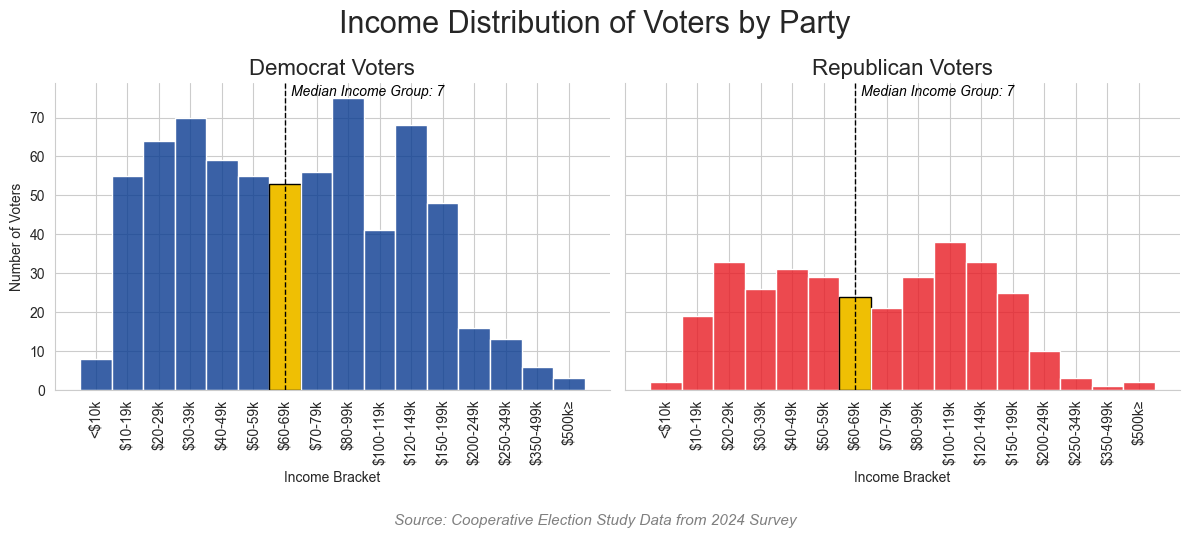

In [152]:
# Basically copy and paste from midterm, but altered it to find the median instead of mean b/c I realized I used the wrong measure of central tendency
plot_df = ces[ces['party_24'].isin([1,2])].copy()
plot_df['Party'] = plot_df['party_24'].map({1: 'Democrat', 2: 'Republican'})
income_labels = [
    "<$10k", "$10-19k", "$20-29k", "$30-39k", "$40-49k", "$50-59k", 
    "$60-69k", "$70-79k", "$80-99k", "$100-119k", "$120-149k", "$150-199k", 
    "$200-249k", "$250-349k", "$350-499k", "$500k≥"]

dem_median = plot_df[plot_df['Party'] == 'Democrat']['income'].median()
rep_median = plot_df[plot_df['Party'] == 'Republican']['income'].median()

g = sns.FacetGrid(
    plot_df,
    col = "Party",
    hue = "Party",
    palette = {'Democrat': '#083A90', 'Republican': '#E81B23'},
    height = 5,
    aspect = 1.2
)
plt.suptitle('Income Distribution of Voters by Party', fontsize = 22)
g.set_titles("{col_name} Voters", size=16)

g.map(sns.histplot, "income", bins = range(1,18), discrete = True, stat='count', common_norm=False, alpha = 0.8, edgecolor = 'white')

#asked Gemini for help to add a trendline to show where the average voter is in each party + color the bar differently 
for ax, party in zip(g.axes.flat, ['Democrat', 'Republican']):
    med_val = dem_median if party == 'Democrat' else rep_median
    med_bracket = int(med_val) 
    ax.axvline(med_val, color='black', linestyle='--', linewidth=1, zorder=3)
    # Find the bar for the median bracket and change its color
    for patch in ax.patches:
        # Check if this bar's center matches our mean bracket
        if abs(patch.get_x() + patch.get_width()/2 - med_bracket) < 0.1:
            patch.set_facecolor('#EFBF04')
            patch.set_alpha(1.0) 
            patch.set_edgecolor('black')
            patch.set_linewidth(1.0)
    # Add text annotation
    ax.text(med_val + 0.2, ax.get_ylim()[1] * 0.96, f'Median Income Group: {med_bracket}', 
            color='black', style = 'italic', fontsize=10)

g.set_axis_labels("Income Bracket", "Number of Voters")
g.set(xticks = range(1,17))
g.set_xticklabels(income_labels, rotation = 90)

caption = ('Source: Cooperative Election Study Data from 2024 Survey')
plt.figtext(0.5, -0.05, caption, ha="center", fontsize=11, style='italic', color='gray')
plt.tight_layout()
plt.show()

# 💰 Economic Policy Analysis

The economic policies under consideration are as follows:

*  Expanding Medicare to Cover All Americans
*  Increasing the Federal Minimum Wage
*  Repealing the Affordable Care Act/Obamacare
*  Withdrawal from the Trans-Pacific Free Trade Agreement
*  Forgive Student Loan Debt up to $20k

Rational Choice Theory would predict that all working-class voters would have a **high support percentage** for Expanding Medicare, Increasing the Federal Minimum Wage, Withdrawal from the Trans-Pacific Free Trade Agreement, and Student Loan Debt Forgiveness, but a **low support percentage** for Repealing the ACA. This is because repealing access to free/reduced-cost healthcare would negatively impact working-class members' access to healthcare at all. Expanding Medicare, increasing the Federal Minimum Wage, and Student Debt Forgiveness would cause direct, positive impacts on working-class members by increasing their access to healthcare, the overall wage minimum for a significant portion of blue-collar workers (who predominantly make up the working class), and could promote continuing education. Free trade agreements are highly contested, but many argue that leaving the Trans-Pacific Trade Agreement could bring back manufacturing jobs to the US, thus increasing job opportunities for the working class.

## Impacts of Family Household Income on Economic Policy Considerations
These charts show the overall support and opposition trends for economic policy between parties. **The Democratic Party tends to support expanding Medicare, protecting the ACA, increasing the minimum wage, and student debt forgiveness, but strongly opposes leaving free-trade agreements.** On the other hand, **the Republican Party tends to support repealing the ACA, not expanding Medicare, and not forgiving student debt, but has mixed feelings about increasing the minimum wage and free-trade agreements.** 

The response from both parties about trade agreements could be explained by the historic trend to promote American isolationism, but the fact that decreased trade could increase the cost of consumer goods that are otherwise imported. As for minimum wage, more Republican working-class voters could support it because it is their main source of income. 

> *Note: Working-Class Independent voters were removed from consideration, because a preliminary analysis showed a roughly 50/50 division on almost every single economic policy consideration. This created an unnecessarily messy visualization of the data and did not show substantive data on economic policy considerations.*

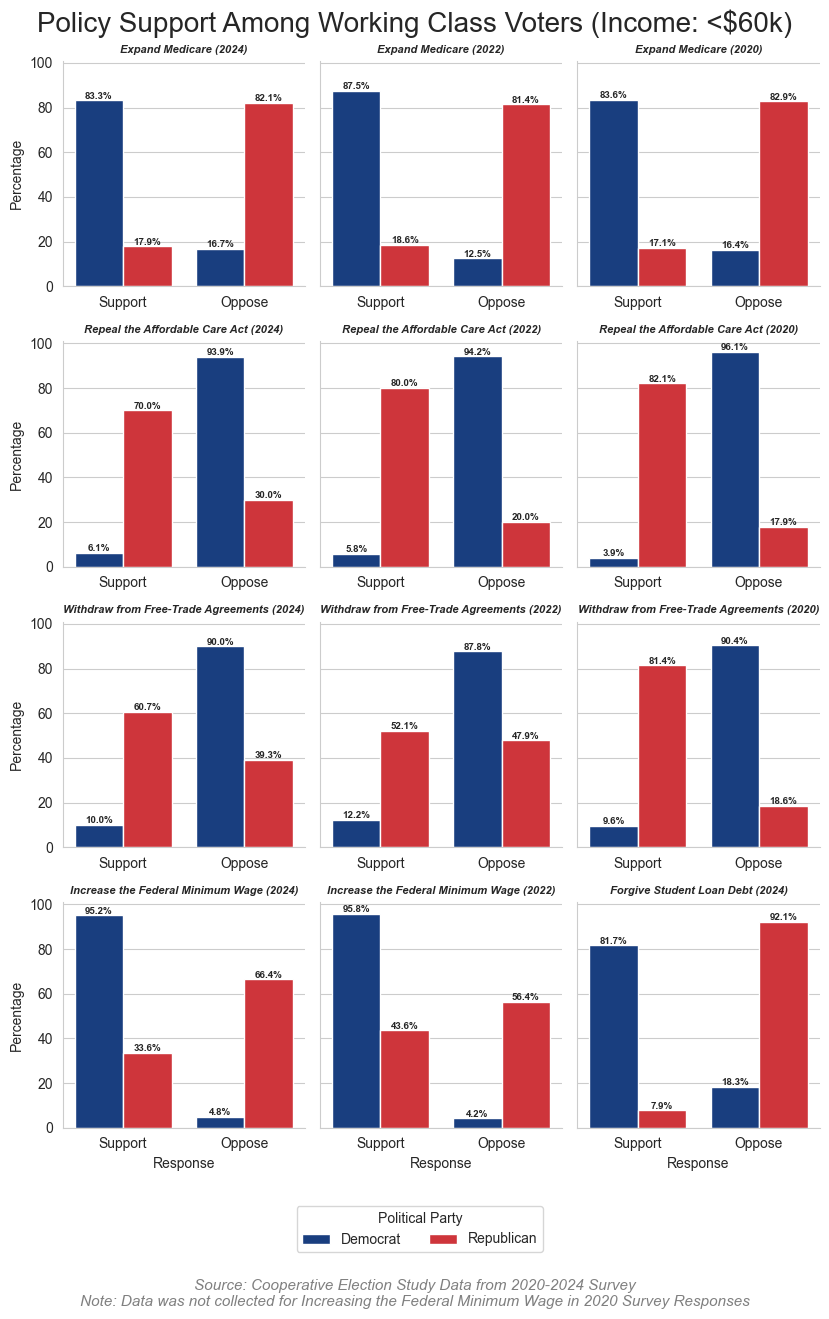

In [31]:
wc_data = ces[(ces['income'] <= 6) & (ces['party_24'].isin([1,2]))].copy()
wc_data['Party'] = wc_data['party_24'].map({1:'Democrat', 2:'Republican'})
policies = {
    'health_24': 'Expand Medicare (2024)',
    'aca_24': 'Repeal the Affordable Care Act (2024)',
    'trade_24': 'Withdraw from Free-Trade Agreements (2024)',
    'minwage_24': 'Increase the Federal Minimum Wage (2024)',
    'health_22': 'Expand Medicare (2022)',
    'aca_22': 'Repeal the Affordable Care Act (2022)',
    'trade_22': 'Withdraw from Free-Trade Agreements (2022)',
    'minwage_22': 'Increase the Federal Minimum Wage (2022)',
    'health_20': 'Expand Medicare (2020)',
    'aca_20': 'Repeal the Affordable Care Act (2020)',
    'trade_20': 'Withdraw from Free-Trade Agreements (2020)',
    'student_debt24': 'Forgive Student Loan Debt (2024)'
}

order = [
    'Expand Medicare (2024)', 'Expand Medicare (2022)', 'Expand Medicare (2020)',
    'Repeal the Affordable Care Act (2024)', 'Repeal the Affordable Care Act (2022)', 'Repeal the Affordable Care Act (2020)',
    'Withdraw from Free-Trade Agreements (2024)', 'Withdraw from Free-Trade Agreements (2022)', 'Withdraw from Free-Trade Agreements (2020)',
    'Increase the Federal Minimum Wage (2024)', 'Increase the Federal Minimum Wage (2022)', 'Forgive Student Loan Debt (2024)'
]

long_df = wc_data.melt(
    id_vars = ['Party'],
    value_vars = list(policies.keys()),
    var_name = 'Policy_id', value_name = 'Rating'
)
long_df['Policy'] = long_df['Policy_id'].map(policies)

long_df['Response'] = long_df['Rating'].map({1: 'Support', 2: 'Oppose'})

# Got help to turn data into percentages for response
counts = long_df.groupby(['Policy', 'Party', 'Response']).size().reset_index(name='count')
totals = long_df.groupby(['Policy', 'Party']).size().reset_index(name='total')
plot_data = counts.merge(totals, on=['Policy', 'Party'])
plot_data['Percentage'] = (plot_data['count'] / plot_data['total']) * 100

g = sns.catplot(
    data = plot_data, x = 'Response', y = 'Percentage', hue = 'Party',
    col = 'Policy', kind = 'bar',
    col_order = order, 
    col_wrap = 3, 
    palette = {'Democrat': '#083A90', 'Republican': '#E81B23'},
    height = 3, aspect = 0.8, order= ['Support', 'Oppose'],
    legend = True
)

# Force adding x-axis to each plot, needed help here
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.subplots_adjust(top=0.85, bottom=0.2)
sns.move_legend(
    g, "lower center", 
    bbox_to_anchor=(.5, 0.05), 
    ncol=2, 
    title=None, 
    frameon=False
)
g._legend.set_bbox_to_anchor((0.5, 0.05))
g._legend.set_title("Political Party")
g._legend.set_frame_on(True)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Policy Support Among Working Class Voters (Income: <$60k)', fontsize = 20)
g.set_titles("{col_name}", size = 8, fontweight='bold', fontstyle='italic')

# Got help to annotate the bars with percentages + kept having random labels show up that weren't supposed to be there
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext= (0,3), # Pushes the text a little higher
                        textcoords = 'offset points',
                        fontsize= 7, 
                        fontweight='bold')

caption = "Source: Cooperative Election Study Data from 2020-2024 Survey\nNote: Data was not collected for Increasing the Federal Minimum Wage in 2020 Survey Responses"
plt.figtext(0.5, -0.1, caption, ha="center", fontsize=11, style='italic', color='gray')

plt.tight_layout()
plt.show()

## Comparison of Economic Policy Support with Education {#education}
By distinguishing by political party, I hoped to find a more visible trend in how working-class voters vote on economic policy considerations, and how that may correlate with educational attainment levels. With this, I controlled for income (less than \$60k) and political party affiliation. The educational attainment levels that are modeled are: "No High School", "High School Graduate", and "Some College", which are levels typically associated with the working-class. Also, I included "Post Graduates" to see if there was any difference in how the "most educated" voters vote compared to the lower end of the spectrum. **By removing the political parties from each other, we can see how varying levels of educational attainment may create economic policy divisions among people in the same party and income bracket.**

### Republican Working-Class Voters
**In all policy areas, working-class members of the Republican party show relatively the same voting behavior *regardless* of educational attainment levels.** This is an important takeaway, as it shows that educational attainment may not affect voting patterns as much as previously thought.

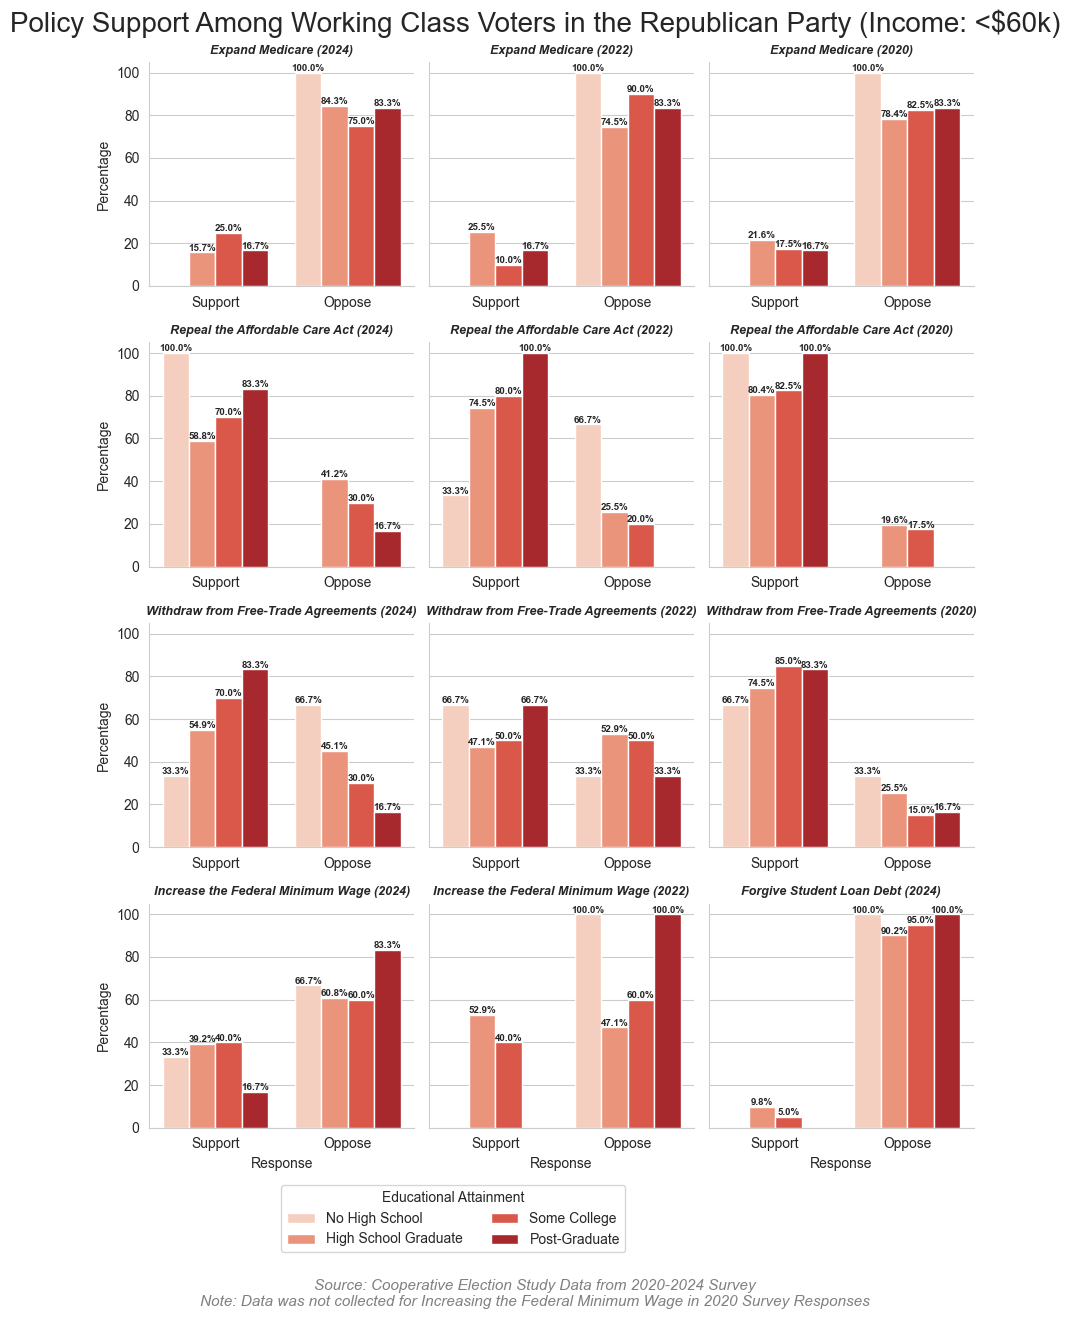

In [151]:
gop_wc = ces[(ces['income'] <= 6) & (ces['party_24'] == 2)].copy()

education = {
    1: 'No High School', 2: 'High School Graduate', 3: 'Some College', 6: 'Post-Graduate'
}
gop_wc['Education'] = gop_wc['educ_24'].map(education)

policies = {
    'health_24': 'Expand Medicare (2024)',
    'aca_24': 'Repeal the Affordable Care Act (2024)',
    'trade_24': 'Withdraw from Free-Trade Agreements (2024)',
    'minwage_24': 'Increase the Federal Minimum Wage (2024)',
    'health_22': 'Expand Medicare (2022)',
    'aca_22': 'Repeal the Affordable Care Act (2022)',
    'trade_22': 'Withdraw from Free-Trade Agreements (2022)',
    'minwage_22': 'Increase the Federal Minimum Wage (2022)',
    'health_20': 'Expand Medicare (2020)',
    'aca_20': 'Repeal the Affordable Care Act (2020)',
    'trade_20': 'Withdraw from Free-Trade Agreements (2020)',
    'student_debt24': 'Forgive Student Loan Debt (2024)'
}

order = [
    'Expand Medicare (2024)', 'Expand Medicare (2022)', 'Expand Medicare (2020)',
    'Repeal the Affordable Care Act (2024)', 'Repeal the Affordable Care Act (2022)', 'Repeal the Affordable Care Act (2020)',
    'Withdraw from Free-Trade Agreements (2024)', 'Withdraw from Free-Trade Agreements (2022)', 'Withdraw from Free-Trade Agreements (2020)',
    'Increase the Federal Minimum Wage (2024)', 'Increase the Federal Minimum Wage (2022)', 'Forgive Student Loan Debt (2024)'
]

long_df = gop_wc.melt(id_vars=['Education'], value_vars=list(policies.keys()), var_name='Policy_id', value_name='Rating')
long_df['Policy'] = long_df['Policy_id'].map(policies)
long_df['Response'] = long_df['Rating'].map({1: 'Support', 2: 'Oppose'})

counts = long_df.groupby(['Policy', 'Education', 'Response']).size().reset_index(name='count')
totals = long_df.groupby(['Policy', 'Education']).size().reset_index(name='total')
plot_data = counts.merge(totals, on=['Policy', 'Education'])
plot_data['Percentage'] = (plot_data['count'] / plot_data['total']) * 100

g = sns.catplot(
    data = plot_data, x = 'Response', y = 'Percentage', hue = 'Education',
    hue_order = ['No High School', 'High School Graduate', 'Some College', 'Post-Graduate'],
    col = 'Policy', col_order = order, col_wrap = 3,
    kind = 'bar', palette = 'Reds', 
    height = 3, aspect = 0.8, order = ['Support', 'Oppose'],
    legend = True
)

# Force adding x-axis to each plot, needed help here
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.subplots_adjust(top=0.85, bottom=0.2)
sns.move_legend(
    g, "lower center", 
    bbox_to_anchor=(.5, 0.05), 
    ncol=2, 
    title=None, 
    frameon=False
)
g._legend.set_bbox_to_anchor((0.5, 0.05))
g._legend.set_title("Educational Attainment")
g._legend.set_frame_on(True)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Policy Support Among Working Class Voters in the Republican Party (Income: <$60k)', fontsize=20)
g.set_titles("{col_name}", size = 9, fontweight='bold', fontstyle='italic')

# Got help to annotate the bars with percentages + kept having random labels show up that weren't supposed to be there
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext= (0,3), # Pushes the text a little higher
                        textcoords = 'offset points',
                        fontsize= 7, 
                        fontweight='bold')

caption = "Source: Cooperative Election Study Data from 2020-2024 Survey\nNote: Data was not collected for Increasing the Federal Minimum Wage in 2020 Survey Responses"
plt.figtext(0.5, -0.1, caption, ha="center", fontsize=11, style='italic', color='gray')

plt.tight_layout()
plt.show()

#### Key Trends
1. **Expand Medicare**: *Regardless of educational background, working-class voters heavily opposed the expansion of Medicare into a universal healthcare program.* This works against members of the working-class, as they typically struggle to have access to healthcare plans otherwise, or use Medicare benefits to have access to healthcare coverage. There is a small percentage of high school graduates and those who have completed some college who support expanding Medicare, but the alarming majority of working-class voters have opposed the idea from 2020 to 2024.
   
2. **Repeal the Affordable Care Act**: *The graphs created for 2024 and 2020 almost mirror each other, with how strongly Republican working-class voters supported repealing the ACA.* This could be due to the rhetoric surrounding the ACA and how it was funded, especially during the Trump Presidency ending in 2020 and Trump's campaign for re-election starting in 2024. *In 2022, however, the results were more divisive across educational backgrounds.* A majority of working-class voters who did not finish high school opposed repealing the ACA. This could be due to the rise of COVID-19 and the need for healthcare benefits to receive treatments during this time. On top of this, the Biden Administration worked heavily to expand and maintain the ACA into a more expansive benefit program, which could have provided working-class members with better access to healthcare coverage. 

3. **Withdraw from Free-Trade Agreements**: *Between 2020 and 2024, there has been an increase in opposition to withdrawal from free-trade agreements among Republican working-class voters who have not graduated high school.* While a similar shift can be noticed in the other educational attainment groups, the most dramatic change in opposition occurred within the "No High School" group. This could be because most people without a high school diploma tend to work in blue-collar jobs, such as those in the trade and manufacturing sectors. Without free-trade agreements, there could be a decline in manufacturing and factory jobs, as well as an increase in cheap goods and skyrocketing market prices. 

4. **Increase the Federal Minimum Wage**: *Between 2020 and 2024, there was a decrease in opposition to increasing the Federal Minimum Wage among Republican working-class voters without a high school diploma.* This change could highlight the fact that members of the working class typically make minimum wage, and an increase to it would only benefit them. 

5. **Forgive Student Loan Debt**: Since there is no prior measurement to compare these results to, the only observational aspect from this graph is that, *regardless of educational attainment, the Republican working-class highly opposes any forgiveness of student loan debt.*

### Democratic Working-Class Voters
**In all policy areas, working-class members of the Democratic Party show the same voting pattern *regardless* of educational attainment levels, more so than working-class Republican voters.** The results in these bar charts show a more unified voting pattern, compared to working-class voters in the Republican Party, across all educational backgrounds. 

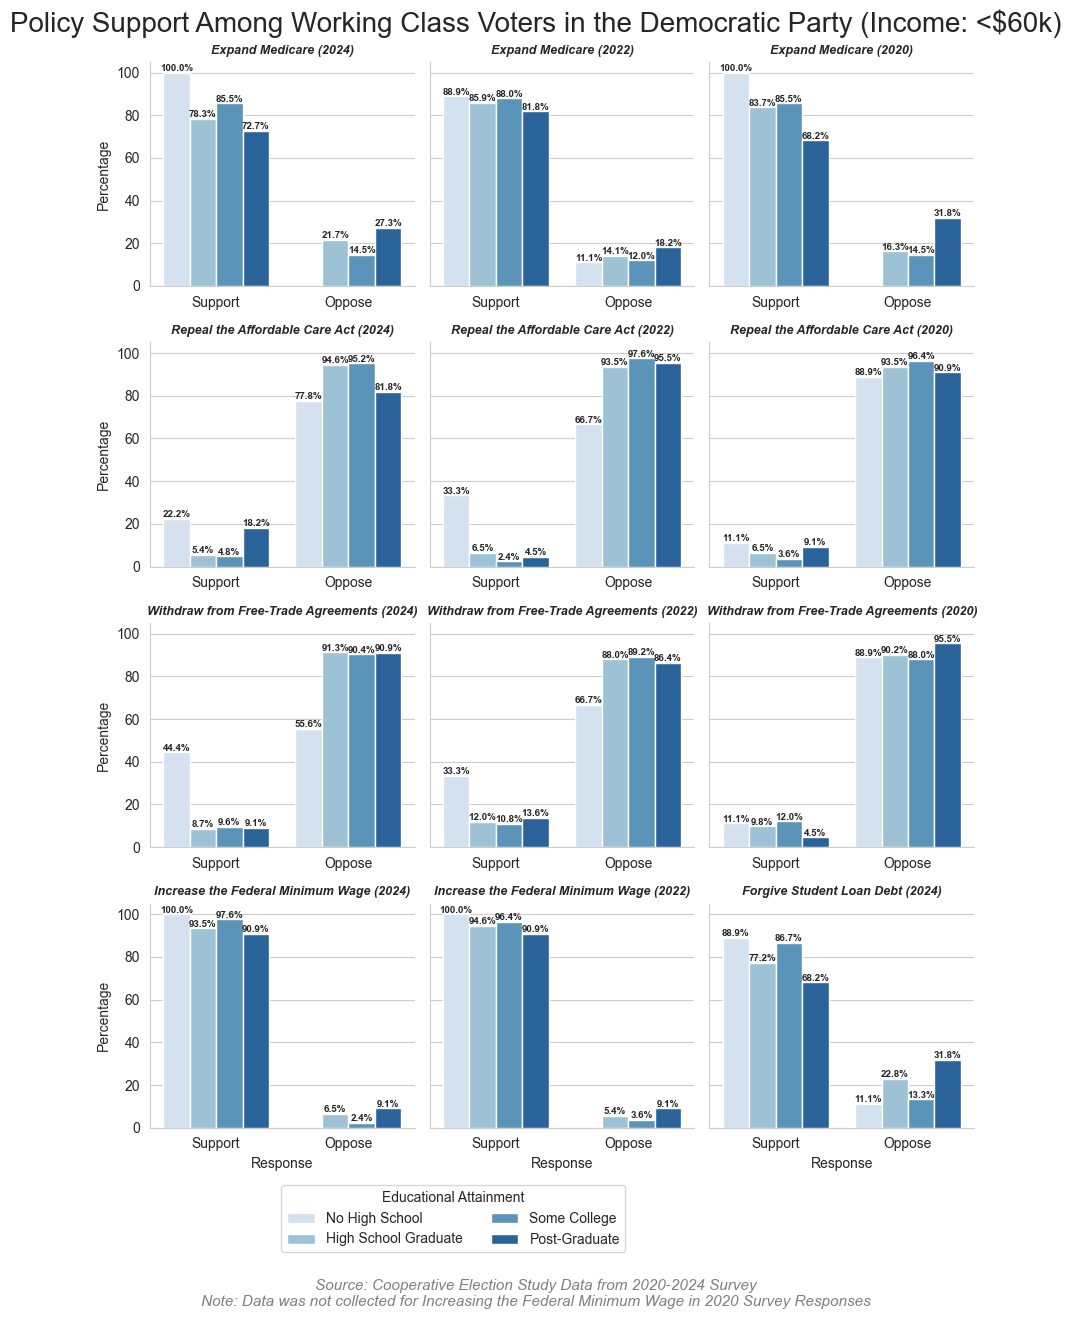

In [149]:
dem_wc = ces[(ces['income'] <= 6) & (ces['party_24'] == 1)].copy()

education = {
    1: 'No High School', 2: 'High School Graduate', 3: 'Some College', 6: 'Post-Graduate'
}
dem_wc['Education'] = dem_wc['educ_24'].map(education)

policies = {
    'health_24': 'Expand Medicare (2024)',
    'aca_24': 'Repeal the Affordable Care Act (2024)',
    'trade_24': 'Withdraw from Free-Trade Agreements (2024)',
    'minwage_24': 'Increase the Federal Minimum Wage (2024)',
    'health_22': 'Expand Medicare (2022)',
    'aca_22': 'Repeal the Affordable Care Act (2022)',
    'trade_22': 'Withdraw from Free-Trade Agreements (2022)',
    'minwage_22': 'Increase the Federal Minimum Wage (2022)',
    'health_20': 'Expand Medicare (2020)',
    'aca_20': 'Repeal the Affordable Care Act (2020)',
    'trade_20': 'Withdraw from Free-Trade Agreements (2020)',
    'student_debt24': 'Forgive Student Loan Debt (2024)'
}

order = [
    'Expand Medicare (2024)', 'Expand Medicare (2022)', 'Expand Medicare (2020)',
    'Repeal the Affordable Care Act (2024)', 'Repeal the Affordable Care Act (2022)', 'Repeal the Affordable Care Act (2020)',
    'Withdraw from Free-Trade Agreements (2024)', 'Withdraw from Free-Trade Agreements (2022)', 'Withdraw from Free-Trade Agreements (2020)',
    'Increase the Federal Minimum Wage (2024)', 'Increase the Federal Minimum Wage (2022)', 'Forgive Student Loan Debt (2024)'
]

long_df = dem_wc.melt(id_vars=['Education'], value_vars=list(policies.keys()), var_name='Policy_id', value_name='Rating')
long_df['Policy'] = long_df['Policy_id'].map(policies)
long_df['Response'] = long_df['Rating'].map({1: 'Support', 2: 'Oppose'})

counts = long_df.groupby(['Policy', 'Education', 'Response']).size().reset_index(name='count')
totals = long_df.groupby(['Policy', 'Education']).size().reset_index(name='total')
plot_data = counts.merge(totals, on=['Policy', 'Education'])
plot_data['Percentage'] = (plot_data['count'] / plot_data['total']) * 100

g = sns.catplot(
    data = plot_data, x = 'Response', y = 'Percentage', hue = 'Education',
    hue_order = ['No High School', 'High School Graduate', 'Some College', 'Post-Graduate'],
    col = 'Policy', col_order = order, col_wrap = 3,
    kind = 'bar', palette = 'Blues', 
    height = 3, aspect = 0.8, order = ['Support', 'Oppose'],
    legend = True
)

# Force adding x-axis to each plot, needed help here
for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)

plt.subplots_adjust(top=0.85, bottom=0.2)
sns.move_legend(
    g, "lower center", 
    bbox_to_anchor=(.5, 0.05), 
    ncol=2, 
    title=None, 
    frameon=False
)
g._legend.set_bbox_to_anchor((0.5, 0.05))
g._legend.set_title("Educational Attainment")
g._legend.set_frame_on(True)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Policy Support Among Working Class Voters in the Democratic Party (Income: <$60k)', fontsize=20)
g.set_titles("{col_name}", size = 9, fontweight='bold', fontstyle='italic')

# Got help to annotate the bars with percentages + kept having random labels show up that weren't supposed to be there
for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  
            ax.annotate(f'{height:.1f}%', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='center', 
                        xytext= (0,3), # Pushes the text a little higher
                        textcoords = 'offset points',
                        fontsize= 7, 
                        fontweight='bold')

caption = "Source: Cooperative Election Study Data from 2020-2024 Survey\nNote: Data was not collected for Increasing the Federal Minimum Wage in 2020 Survey Responses"
plt.figtext(0.5, -0.1, caption, ha="center", fontsize=11, style='italic', color='gray')

plt.tight_layout()
plt.show()

#### Key Trends
1. **Repealing the ACA**: A small, yet noticeable, portion of non-high school graduates supported repealing the ACA in 2022, which does not fit the rest of the voters in varying educational backgrounds. This support percentage decreased in 2024, but remains high enough to discuss.

2. **Withdrawal of Free-Trade Agreements**: Between 2020 and 2024, non-high school graduates had a steadily increasing support to withdraw from Free-Trade Agreements. In 2024, just under half of the non-high school graduate working-class voters supported withdrawing from free-trade agreements. This does not fit the rest of the trend, but could be due to the desire to uphold "America first" ideology without realizing the impact it may have on manufacturing jobs and the US economy.

3. **Forgiving Student Loan Debt**: A small number of high school graduates, those who completed some college, and those with post-graduate degrees opposed forgiving student loan debt. For both, it could be due to the internal thought process of voters not wanting to pay for others (through tax funding) college costs, when they themselves did not go to college/complete college. Some existing research shows similar trends, specifically the Brookings Institution and Progressive Policy Institute's Research, showing that [56% of Democrat working-class voters](https://www.brookings.edu/articles/what-todays-working-class-wants-from-political-leaders/) tend to oppose student debt relief.

# 𐦂𖨆𐀪𖠋 Does Social Policy Predict Economic Decisions? {#social}
Social policy considerations may influence the decision-making process of working-class voters. Some scholars argue that social policy holds more weight when it is time to vote, so much so that it influences an individual's vote entirely away from other policies that may provide them with direct benefits. To test this theory, a simple machine learning model was created to test if social policy decisions could predict the way that the working class votes on economic policies. 

The social policies under consideration are as follows:

* Increase the Access to Concealed Carry Permits
* Enstate an Universal Abortion Ban
* Construct a Border Wall Between the US/Mexico
  
> *Note: These policies were chosen due to their nature of being the most controversial/creating the highest amount of divisiveness between political parties* 

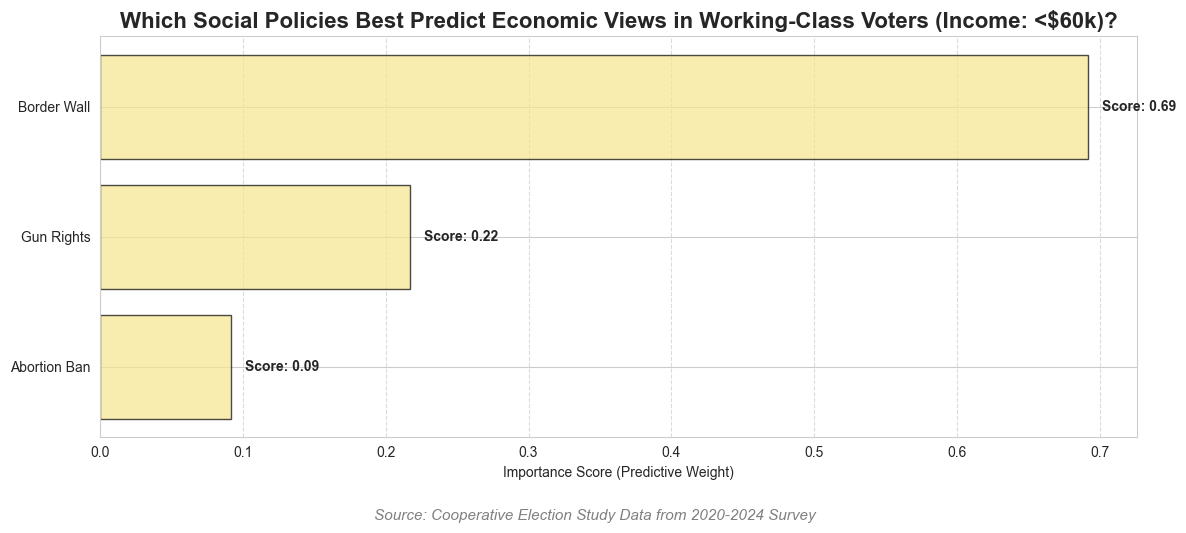

In [57]:
from sklearn.ensemble import RandomForestRegressor

wc_data = ces[ces['income'] <= 6].copy()

social = ['concealed_24', 'abortion_24', 'wall_24']
econ = ['health_24', 'aca_24', 'trade_24', 'minwage_24', 'student_debt24']
plot_data = wc_data[social + econ].copy()
plot_data['Econ_Index'] = plot_data[econ].mean(axis=1)

X = plot_data[social]
y = plot_data['Econ_Index']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Gemini help here - should tell us which social policy is the best 'predictor'
importances = pd.Series(model.feature_importances_, index=['Gun Rights', 'Abortion Ban', 'Border Wall'])
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(importances.index, importances.values, color= '#F6E58D', alpha=0.7, edgecolor='black')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01,           
            bar.get_y() + bar.get_height()/2, 
            f'Score: {width:.2f}',         
            va='center',            
            fontsize= 10, 
            fontweight='bold')

plt.title('Which Social Policies Best Predict Economic Views in Working-Class Voters (Income: <$60k)?', fontsize=16, weight = 'bold')
plt.xlabel('Importance Score (Predictive Weight)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

caption = "Source: Cooperative Election Study Data from 2020-2024 Survey"
plt.figtext(0.5, -0.05, caption, ha="center", fontsize=11, style='italic', color='gray')

plt.tight_layout()
plt.show()

## Interpretation of the Model
**This model shows that, while there is some influence of perceptions of social policies on economic considerations, the weightage for the social policies is not uniform.** The *strongest predictor* of an individual's perception of economic policy *is their feelings about constructing a border wall between the US and Mexico.* This means that working-class voters who support the construction of the border wall are more likely to also hold conservative views on the economy. However, gun rights and abortion bans have a lower predictive weight on economic policy considerations. This can be interpreted as how intertwined social and economic policies are in the minds of working-class voters, making it hard to use those social policies as accurate predictors.

# 📰 Does Media Consumption Predict Economic Decisions? {#media}
Media consumption is not something heavily considered in existing literature to understand why the working-class votes against economic policy that would otherwise benefit them; *however*, I was interested to see if a relationship existed. With this, I pulled data from the CES survey on questions that asked respondents about where they got a majority of their news. 

The data I used to test this only gathered responses for the top four news networks: **ABC, CBS, NBC, and Fox News.** ABC, NBC, and CBS are all considered to be Left-leaning news networks, while Fox News is considered to be a strongly Right news network. I used the same ML method as the previous section to create a prediction measure on how well certain news outlets can predict the way working-class members vote on economic policies. 

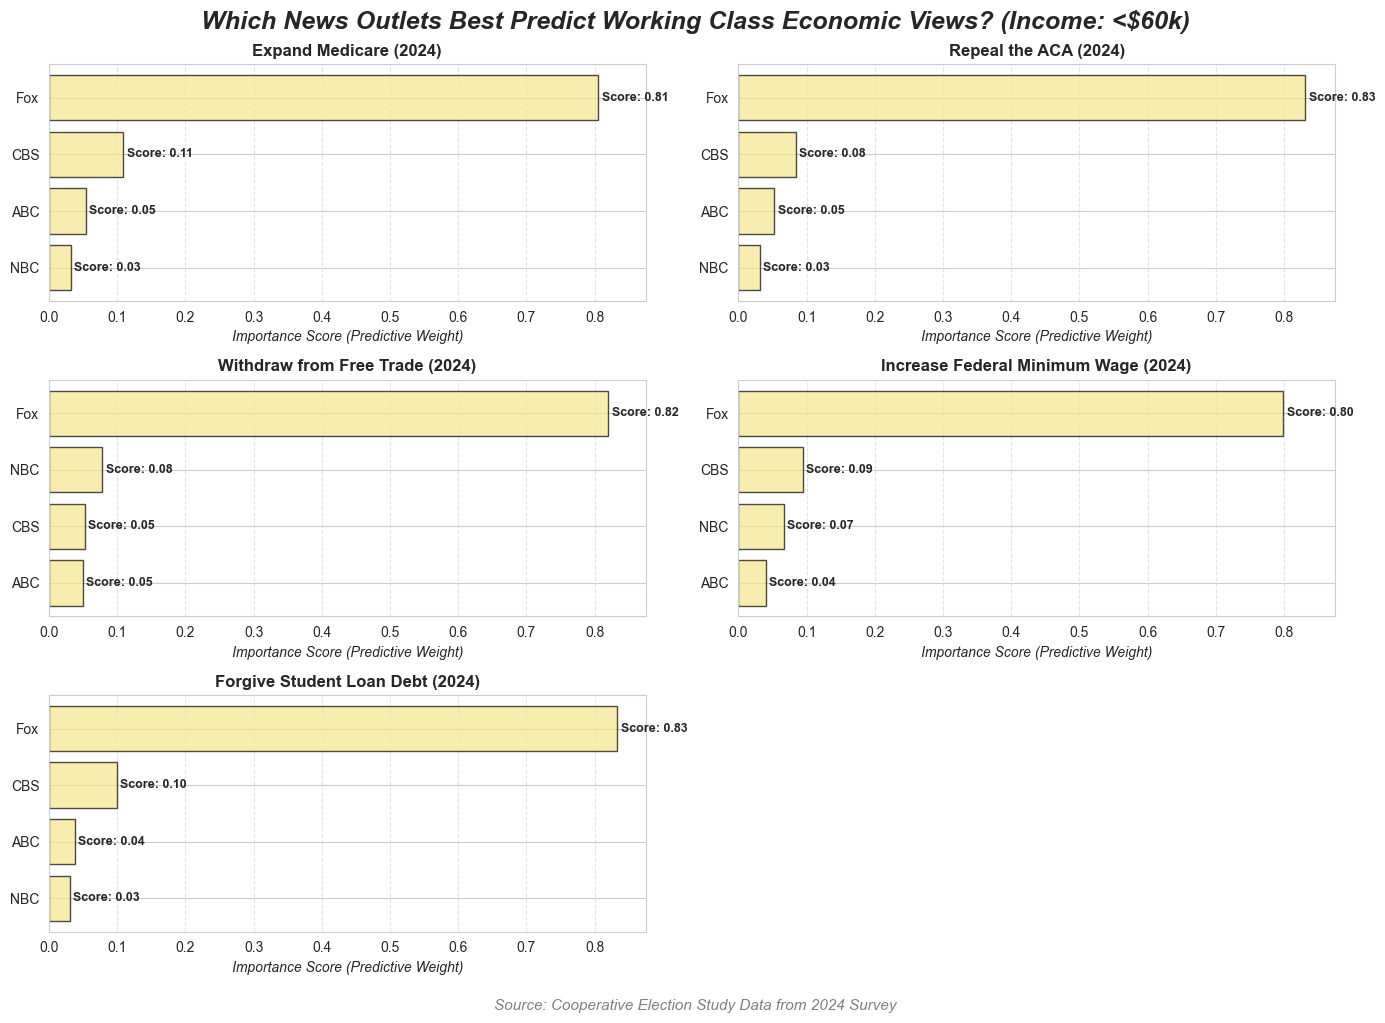

In [61]:
from sklearn.ensemble import RandomForestRegressor

wc_data = ces[ces['income'] <= 6].copy()

news = ['abc_24', 'nbc_24', 'cbs_24', 'fox_24']
news_label = ['ABC', 'NBC', 'CBS', 'Fox']
econ = {
    'health_24': 'Expand Medicare (2024)',
    'aca_24': 'Repeal the ACA (2024)',
    'trade_24': 'Withdraw from Free Trade (2024)',
    'minwage_24': 'Increase Federal Minimum Wage (2024)',
    'student_debt24': 'Forgive Student Loan Debt (2024)'
}

fig, axes = plt.subplots(nrows= 3, ncols= 2, figsize=(14, 10), sharex= True)
axes = axes.flatten()

for i, (col, title) in enumerate(econ.items()):
    plot_data = wc_data[news + [col]].copy()
    X = plot_data[news]
    y = plot_data[col]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=news_label).sort_values()
    
    ax = axes[i]
    bars = ax.barh(importances.index, importances.values, color='#F6E58D', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Importance Score (Predictive Weight)', fontsize=10, style = 'italic') 
    ax.tick_params(labelbottom=True)
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
                f'Score: {width:.2f}', va = 'center', fontsize = 9, fontweight='bold')
    
    ax.set_title(title, fontsize=12, weight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

axes[5].set_visible(False) # gets rid of random blank graph

plt.suptitle('Which News Outlets Best Predict Working Class Economic Views? (Income: <$60k)', 
             fontsize=18, weight = 'bold', style = 'italic')

caption = "Source: Cooperative Election Study Data from 2024 Survey"
plt.figtext(0.5, -0.02, caption, ha="center", fontsize=11, style='italic', color='gray')

plt.tight_layout()
plt.show()

## Interpretation of the Model
All five visualizations show that **Fox News is the strongest predictor of how someone in the working class will vote on all economic policies**. This result is *not surprising*, as it is the only news network in consideration that was strongly conservative. **This shows that consumption of highly partisan affiliated news networks can impact the way voters choose to vote.** The rhetoric spread on networks, like Fox, can alter the way certain policies are interpreted by the public, so much so that it can convince members of the working class to vote against economic policies that would otherwise benefit them if passed. 

The other news networks (ABC, CBS, NBC) have **less of an effect** on predicting economic policy decision-making within the working class. Depending on the policy in question, each network has a different weightage; however, nothing is as strong as the effect of Fox News on the predictive model. This could be because the networks are less politically affiliated (Left-leaning instead of strong Left), which could influence the rhetoric that is produced about specific economic policies. At the same time, those who vote against economic parties tend to already be affiliated with the Republican Party, making it less likely that they are watching ABC, CBS, or NBC overall. 

# 💭 What Impacts Economic Policy Voting the Most? 
The previous visualizations show the impact they have individually on predicting how working-class members tend to vote on economic policies. The purpose of this heatmap is to **show how strong those relationships are on economic policy outcomes, and if there is one variable that acts as the "strongest predictor" or influence on how individuals vote on policies.** 

This was done by checking each factor (social policies, educational attainment, news consumption, and economic policies) against the others. Despite looking complex, each component of the heatmap is relatively easy to understand. 

* **Color Scale + Score Values**: The diverging color palette from green to purple shows the strength of the Pearson Correlation Coefficient. The Pearson Correlation Coefficient exists on a scale *between -1 and 1*, where ***a score of -1 shows a perfect, negative correlation (green) and a score of 1 shows a positive, perfect correlation (purple). The closer each value is to one of the poles, the stronger the relationship is.***
    * The diagonal, purple line that exists within the heatmap shows a perfect, positive correlation. This is because each variable is being tested against itself here. 
* **Asterisks**: The asterisks located in the bottom middle of each heatmap tile represent the p-value associated with each relationship test. ***The p-value indicates whether or not a relationship between two variables is statistically significant or not. All boxes containing asterisks are variables that have a statistically significant relationship.***
    * **If p < 0.05 (\*\*)**: This is the baseline threshold that must be met for a relationship to be considered statistically significant. 
    * **If p < 0.01 (\*\*\*)**: This indicates the relationship that exists between the two variables is more statistically significant than the others. *In other words, there is a 1% chance these results occurred by chance.* 

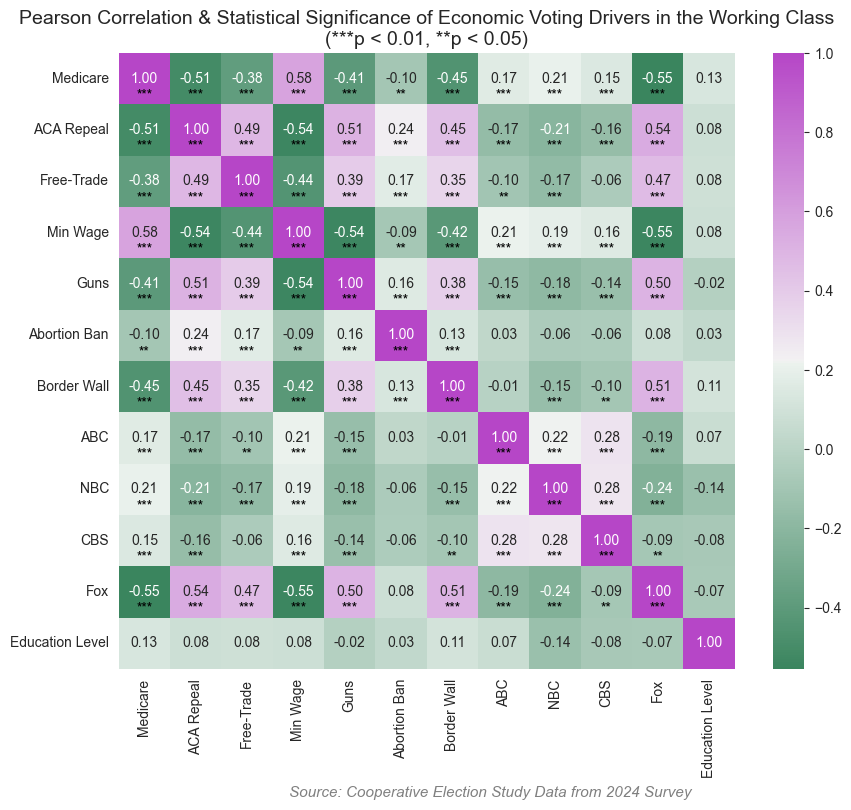

In [158]:
from scipy.stats import pearsonr # idk if I need this, but I will come back

wc = ces[ces['income'] <= 6].copy()
econ = {'health_24': 'Medicare', 'aca_24': 'ACA Repeal', 
             'trade_24': 'Free-Trade', 'minwage_24': 'Min Wage'}
social = {'concealed_24': 'Guns', 'abortion_24': 'Abortion Ban', 
               'wall_24': 'Border Wall'}
media = {'abc_24': 'ABC', 'nbc_24': 'NBC', 'cbs_24': 'CBS', 'fox_24': 'Fox'}
education = {'educ_24': 'Education Level'}

all_vars_map = {**econ, **social, **media, **education}
cols = list(all_vars_map.keys())

subset = wc[cols].copy()
for col in cols: # changing 2 to 0 for oppose 
    subset[col] = subset[col].map({1: 1, 2: 0})

# Needed help for stuff below this comment to calculate p-values
corr_matrix = subset.corr(method = 'pearson')
p_matrix = pd.DataFrame(index = cols, columns = cols, dtype = float) 

for c1 in cols:
    for c2 in cols:
        corr, pval = pearsonr(subset[c1], subset[c2])
        p_matrix.loc[c1, c2] = pval 

corr_matrix.columns = corr_matrix.index = [all_vars_map[c] for c in cols]
p_matrix.columns = p_matrix.index = [all_vars_map[c] for c in cols]

sig_labels = np.where(p_matrix < 0.01, '***', 
             np.where(p_matrix < 0.05, '**', ''))

plt.figure(figsize=(10, 8))
custom_cmap = sns.diverging_palette(145, 300, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap= custom_cmap, square=True)

# overlay the astreks 
for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j+0.5, i+ 0.9, sig_labels[i, j], ha = 'center', color = 'black')

plt.title('Pearson Correlation & Statistical Significance of Economic Voting Drivers in the Working Class\n(***p < 0.01, **p < 0.05)', fontsize=14)

caption = "Source: Cooperative Election Study Data from 2024 Survey"
plt.figtext(0.5, -0.05, caption, ha="center", fontsize=11, style='italic', color='gray')
plt.show()

## Key Takeaways {#heatmap}
* The **strongest relationship** between two variables was ***increasing* the Federal Minimum Wage and the *expansion* of Medicare.**
    * This relationship had a Pearson Correlation Coefficient of *r = 0.58 and a p-value of < 0.01*, indicating a strong, positive, and statistically significant relationship.
* The next strongest relationship between two variables was **a tie between watching Fox News and *rejecting* the expansion of Medicare, and Fox News and the *rejection* of increasing the Federal Minimum Wage**
    * Both relationships had a Pearson Correlation Coefficient of *r = -0.55 and a p-value of < 0.01*, indicating a moderate, negative, and statistically significant relationship between both variables
* After that, there was another tie between **voters who support the *increase* of the Federal Minimum Wage and *reject* the repealling of the ACA**, **voters who *support* increased access to concealed carry permits and *reject* the increase of the Federal Minimum Wage,** and **voters who watch Fox News and *support* the repealling of the ACA.**
    * The first two relationships had a Pearson Correlation Coefficient of *r = -0.54 and a p-value of < 0.01*, indicating a moderate, negative, and statistically significant relationship between both variables
    * The relationship between Fox News and Repealing the ACA had a Pearson Correlation Coefficient of *r = 0.54 and a p-value of < 0.01*, indicating a moderate, positive, and statistically significant relationship

*Other relationships that are important to point out include:*

* **Repealing the ACA** and **Expanding Medicare** (r = -0.51, p < 0.01)
* **Increasing access to concealed carry permits** and **Repealing the ACA** (r = 0.51, p < 0.01)
* **Building a US/Mexico border wall** and **Expanding Medicare** (r = -0.45, p < 0.01)
* **Building a US/Mexico border wall** and **Repealing the ACA** (r = 0.45, p < 0.01)
* **Watching Fox News** and **Leaving Free-Trade Agreements** (r = 0.47, p < 0.01)
* **Watching Fox News** and **Increasing access to concealed carry permits** (r = 0.5, p < 0.01)
* **Watching Fox News** and **Building a US/Mexico border wall** (r = 0.51, p < 0.01)

It is important to note that **educational attainment** had **no relationship with any other variables considered in the study.** This finding contrasts with previous scholarly research that attributes working-class voting methods to the "Diploma Divide" (divisions in educational attainment). 

# 📝 Final Statements
In this study, we have explored several possibilities to understand the shift in working-class voting trends to better resolve why the working class tends to vote against economic policies that would otherwise benefit them. This question has been at the forefront of political scientists' minds for the last few decades following the [Vietnam War](#history), and more so as we have entered an uncharted timeline of politics. Using previous research, I compiled the most utilized explanations to understand the shift in voting behavior ([Diploma divide](#education) and [social policy](#social)), as well as exploring my own considerations ([news/media consumption](media)) to answer this question. 

## Summary of the Results
This study showed that the strongest influence on how the working-class votes on economic policy is [other economic policy considerations](#heatmap). This was followed by the influence of news outlets, specifically Fox News, on how voters view issues like Medicare and the Federal Minimum Wage. These findings were particularly interesting, as they [dismissed education having any relationship](#heatmap) in the way that working-class voters view economic policy. 

The visualizations created within the [education section](#education) show that different levels of education rarely impact the way that people tend to vote on policy compared to various levels of education within the working-class and on the higher end of education completion. With this, there was hardly any variation in the trend across all education levels between the two parties. 

The results from the [social policy](#social) considerations showed that predictive models are able to accurately guess voting behavior on economic policy outcomes only with certain measures of social policy. The ML model found that building a border wall was the best predictor of perception towards pro-working-class economic policy. 

Lastly, the results from the [media consumption](#media) section show that each news outlet has a different effect on predicting the working-class perception of economic policies. Overall, Fox News had the strongest influence on predictive voting behavior. 

## Limitations
One of the biggest limitations of this study is the heavy [Democratic majority](#map1) found within the sample of the CES data. Having a majority of the respondents affiliated with the same political party means that the sample of Republican voters was much smaller, therefore, not fully representative of the United States. While CES does include weightage to fix this, having working-class Republicans and Republicans, in general, in the minority is not helpful when they are the main focus of study. 

On top of this, the CES survey only contains data from 2020 to 2024, which is not a very expansive timeline to fully understand the shift in voting behavior. This timeframe only covers the end of President Trump's first term and President Biden's term in office, which has been one of the most turbulent years in politics. To get a better picture of the shift within the working class, it would be more beneficial to study the trend over a longer period of time. 